## Heart Disease Diagnostic Analysis
An Exploratory Data Analysis (EDA) and Dimensionality Reduction project identifying high-risk patient profiles.

### Why this project matters?:
Heart failure increases in prevalence as individuals get older in the UK and affects 1 in 5 in Europe[1]. In the UK, heart failure impacts a 920,000 people and there are 200,000 new cases every year. Due to an ageing population, it is predicted that diagnosed cases will double by 2040 [2].

There is lots of datasets available but not analysed to the point of findings relating factors/unknown triggers for heart failure. This project sets out to analyse such a dataset and identify an insights found.

### Key insights:
1) Heatmap shows Exercise angina, oldpeak, sex, age and fastingBS are the strongly correlated to heart failure while st_slope, maxhr and chestpain type are least correlated.
2) 2D 2 component and 3 component and 3D PCA plots shows two distinct groups between those with heart disease and those without, suggesting that there is some relation in all of these parameters that links them to heartdisease or not
3) Feature engineering histograms show that being 51-60, having stage 2 resting blood pressure and cholestrol levels below 200 means a higher heart failure prevalence


### References

[1] [https://cks.nice.org.uk/topics/heart-failure-chronic/background-information/prevalence/]

[2] [https://www.england.nhs.uk/nhs-at-home/managing-heart-failure-at-home/]

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import OrdinalEncoder
from scipy.stats import chi2_contingency, ttest_ind
from sklearn.preprocessing import OrdinalEncoder

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv


In [2]:
Heart_df = pd.read_csv('/kaggle/input/datasets/fedesoriano/heart-failure-prediction/heart.csv')

In [3]:
Heart_df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [4]:
print(Heart_df.shape)
print(f"Heart_df.info()\n")
print(Heart_df.describe())

(918, 12)
Heart_df.info()

              Age   RestingBP  Cholesterol   FastingBS       MaxHR  \
count  918.000000  918.000000   918.000000  918.000000  918.000000   
mean    53.510893  132.396514   198.799564    0.233115  136.809368   
std      9.432617   18.514154   109.384145    0.423046   25.460334   
min     28.000000    0.000000     0.000000    0.000000   60.000000   
25%     47.000000  120.000000   173.250000    0.000000  120.000000   
50%     54.000000  130.000000   223.000000    0.000000  138.000000   
75%     60.000000  140.000000   267.000000    0.000000  156.000000   
max     77.000000  200.000000   603.000000    1.000000  202.000000   

          Oldpeak  HeartDisease  
count  918.000000    918.000000  
mean     0.887364      0.553377  
std      1.066570      0.497414  
min     -2.600000      0.000000  
25%      0.000000      0.000000  
50%      0.600000      1.000000  
75%      1.500000      1.000000  
max      6.200000      1.000000  


### Find outliers within numerical labels

In [5]:
# Get numerical/continuous labels
numerical_labels = ['RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']

# Calculate IQR for each label
Q1 = Heart_df[numerical_labels].quantile(0.25)
Q3 = Heart_df[numerical_labels].quantile(0.75)
IQR = Q3 - Q1
Lower_Bound = Q1 - (1.5 * IQR)
Upper_Bound = Q3 + (1.5 * IQR)

# Now find outliers
outliers = ((Heart_df[numerical_labels] < Lower_Bound) | (Heart_df[numerical_labels] > Upper_Bound)).sum()
outlier_percentages = (outliers/len(Heart_df)) * 100

outliers_df = pd.DataFrame({
    'Column' : numerical_labels,
    'Outlier_Percentage' : outlier_percentages
})

outliers_df

,Column,Outlier_Percentage
RestingBP,RestingBP,3.050109
Cholesterol,Cholesterol,19.934641
MaxHR,MaxHR,0.217865
Oldpeak,Oldpeak,1.742919


## Make bar plot to show outlier percentages

<BarContainer object of 4 artists>

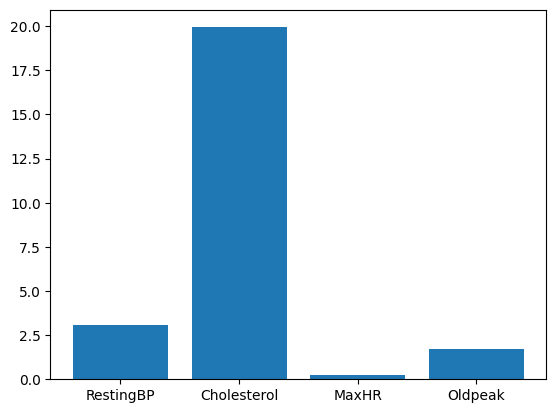

In [6]:
plt.bar(outliers_df.Column, outliers_df.Outlier_Percentage)

### Pie chart for label distribution

([<matplotlib.patches.Wedge at 0x79a8dd579dc0>,
 [Text(-0.18359412736194164, 1.084570512414111, 'Healthy'),
  Text(0.18359448075986173, -1.0845704525914934, 'Disease')])

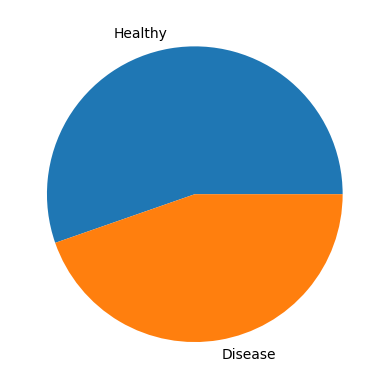

In [7]:
labels_df = Heart_df.HeartDisease.copy()
labels_count = labels_df.value_counts()
labels = ['Healthy', 'Disease']

plt.pie(labels_count, labels = labels)


Labels not evenly distributed

## Feature distribution by label type for continous features

In [8]:
cols = list(Heart_df.columns)
print (cols)
continous_cols = Heart_df.columns[[0, 3,4,7,9]].tolist()
print (continous_cols)

# keep age,resting bp, cholesterol, maxhr, oldpeak, 

unique_labels = labels_df.unique().tolist()
labels = ['No', 'Yes']
unique_labels

['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope', 'HeartDisease']
['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak']


[0, 1]

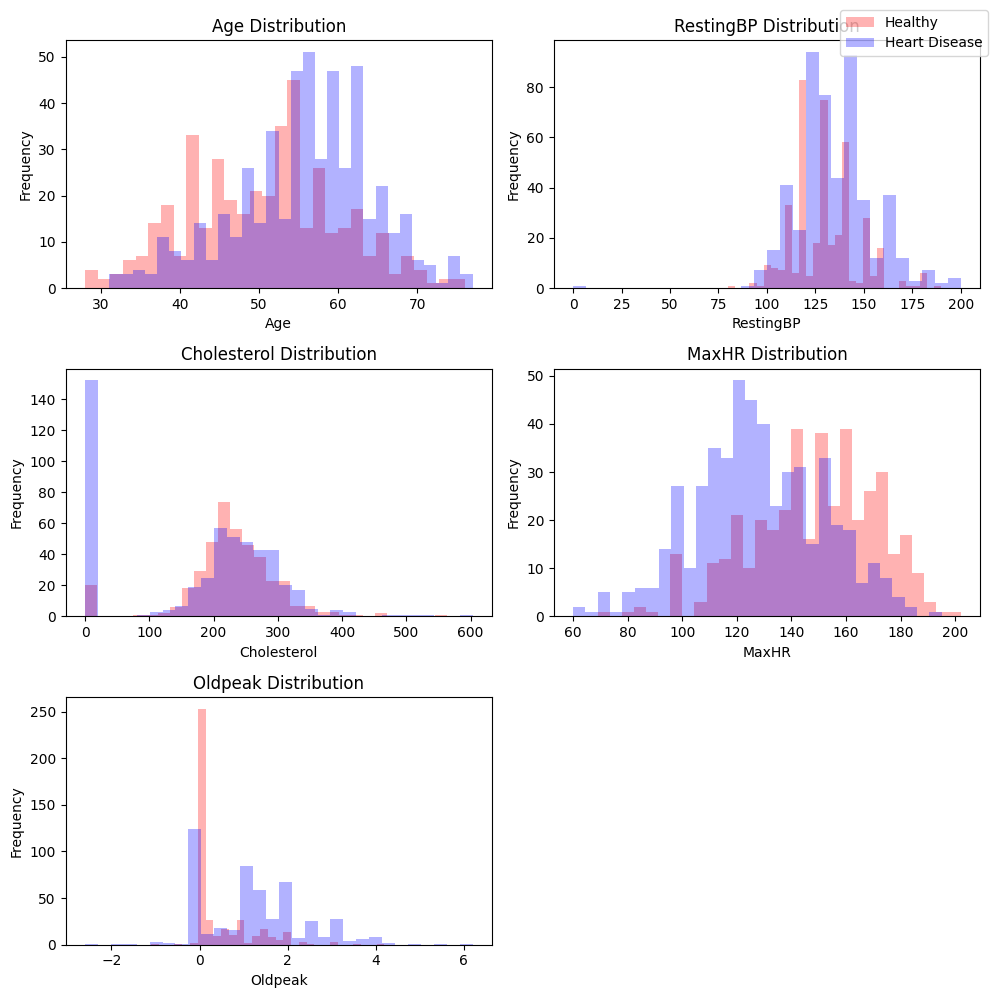

In [9]:
## Make loop and display hists for continuous features

# Separate by label
healthy = Heart_df[Heart_df.HeartDisease == unique_labels[0]]
unhealthy = Heart_df[Heart_df.HeartDisease == unique_labels[1]]

# Create figure made up of empty sublots
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.flatten()  # Flatten axes array for easy iteration

for idx, i in enumerate(continous_cols):
    ax = axes[idx]
    
    # Add labels here! 
    ax.hist(healthy[i], bins=30, alpha=0.3, color='red', label='Healthy')
    ax.hist(unhealthy[i], bins=30, alpha=0.3, color='blue', label='Heart Disease')
    
    ax.set_title(f"{i} Distribution")
    ax.set_xlabel(i)
    ax.set_ylabel("Frequency")


# If you have 5 columns but a 3x2 grid (6 spots), hide the last one:
if len(continous_cols) < len(axes):
    axes[-1].set_axis_off()

## another way looping and making plots, not too much as a fan compared to the old way i was doing it,
## need to do some more work and compare both methods 
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper right', bbox_to_anchor=(1, 1))

# now need to do bar charts for
fig.tight_layout()


Most distributions are similar in shape, with the exception of MaxHR where having a higher heart rate increases risk of heart failure

## Categorical feature distribution by label type - Grouped bar chart

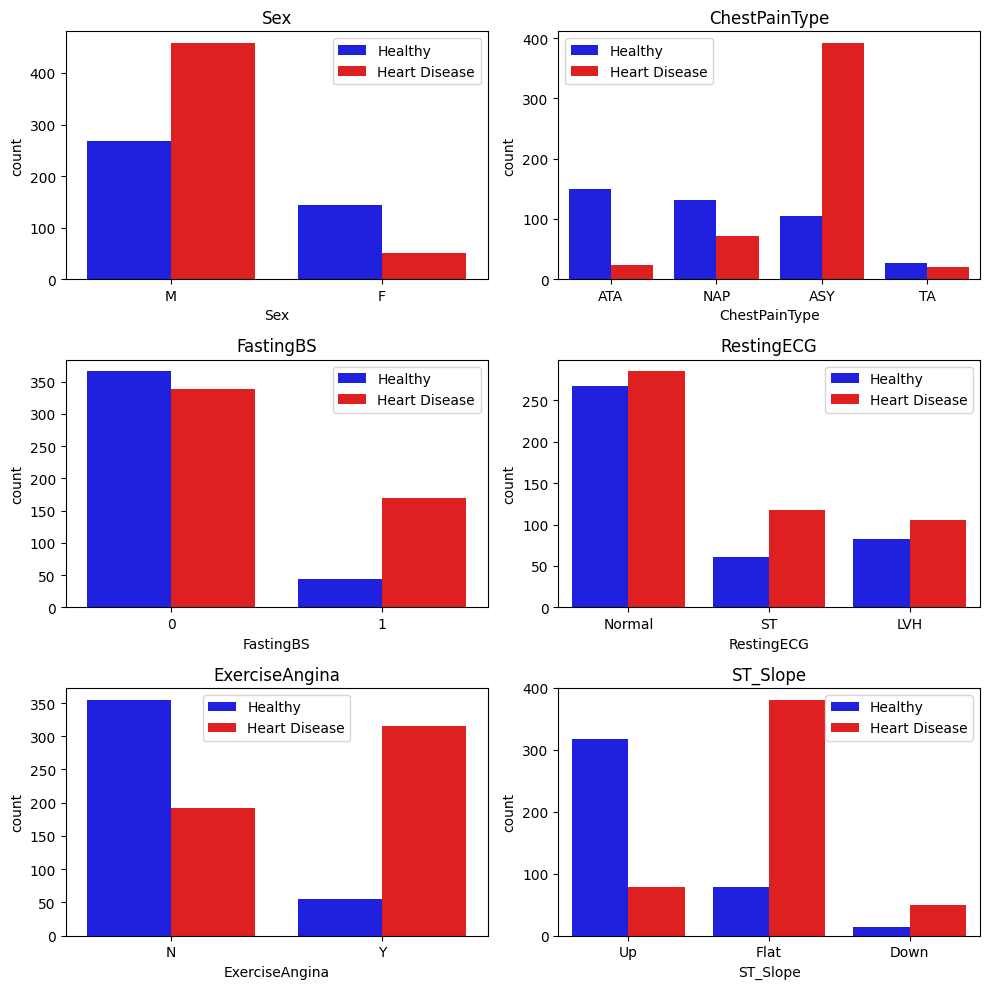

In [10]:
categorical_cols = [i for i in cols if i not in continous_cols]
label = categorical_cols.pop() 

# Create figure made up of empty sublots
fig, axes = plt.subplots(3, 2, figsize=(10, 10))
axes = axes.flatten()  # Flatten axes array for easy iteration

for idx, col in enumerate(categorical_cols):
    ax = axes[idx]
    sns.countplot(data=Heart_df, x=col, hue=label, ax=ax, palette=['blue', 'red'])

    ax.set_title(col)
    ax.legend(['Healthy', 'Heart Disease'])

plt.tight_layout()
plt.show()

### Findings:
- Males more likely to have heart disease
- ASY chest pain type more likely to have heart disease
- High fasting blood sugar more likely to have heart disease
- Higher proportion of ST resting ECG has heart disease
- More proportion of individuals with exercise angina has heart failure
- Flat st_slope has higher chance of heart failure, for up, more likely to be healthy and not much different for down st_slope.


<Axes: >

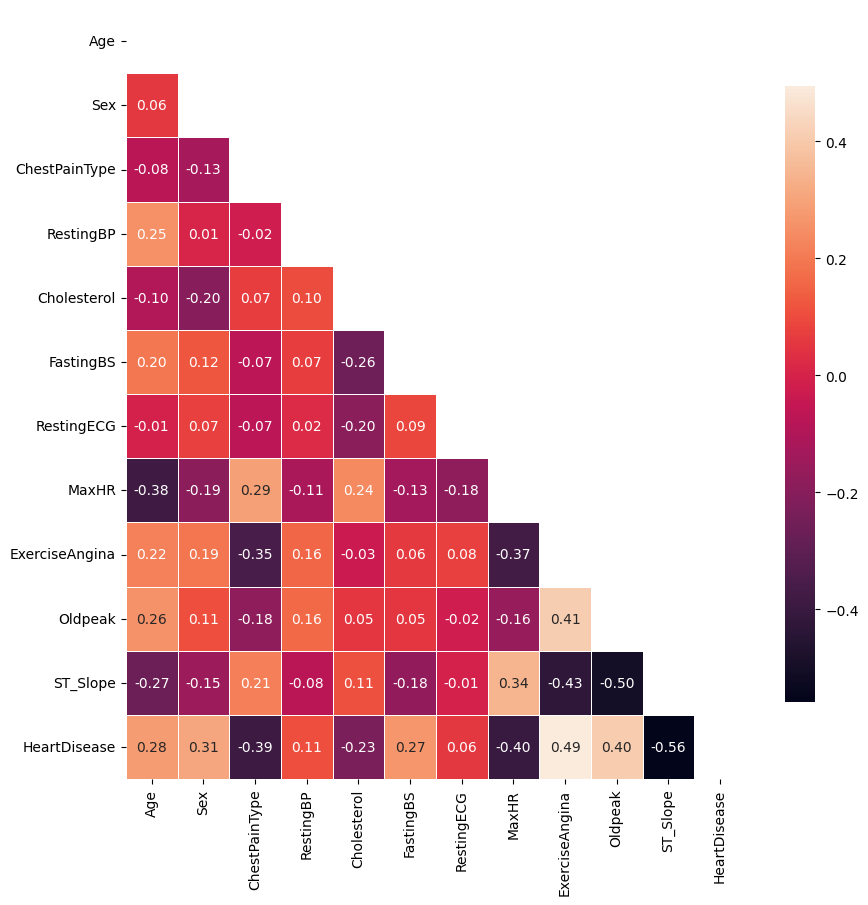

In [11]:
ordinal_encoder = OrdinalEncoder()

# get cols with words
word_cols = [col for col in cols if not isinstance(Heart_df[col][0], (int, np.integer, float))]

copy_df = Heart_df.copy()

copy_df[word_cols] = ordinal_encoder.fit_transform(copy_df[word_cols])

corr = copy_df.corr()
mask = np.triu(np.ones_like(corr, dtype=np.bool))

plt.figure(figsize=[10,10])
sns.heatmap(corr, annot=True, mask=mask, fmt=".2f",
            square=False, linewidths=.5, cbar_kws={"shrink": .8},
            annot_kws={"size": 10})

Heart Disease has the highest correlation with:
- Exercise Angina
- OldPeak
- Sex
- Age
- FastingBS

Heart Disease has negative correlation with:
- ST_Slope
- MaxHR
- ChestPainType
- Cholesterol

### Chi-sqaured of independance for each variable with heart disease

In [12]:
for i in categorical_cols:

    contingency_df = pd.crosstab(Heart_df[label], Heart_df[i])
    
    # Performing Chi-Square Test
    chi2_stat, p_value, dof, _ = chi2_contingency(contingency_df)
    
    # Displaying results
    print(f"\nChi-Square result between {i} and {label}")
    print(f"Chi-Square Statistic: {chi2_stat:.4f}")
    print(f"Degrees of Freedom: {dof}")
    print(f"P-value: {p_value:.4f}")
    
    # Significance level
    alpha = 0.05
    
    # Decision
    if p_value <= alpha:
        print(f"Reject H0: There is a significant association between {i} and {label}.")
    else:
        print(f"Fail to Reject HO: No significant association between {i} and {label}.")


Chi-Square result between Sex and HeartDisease
Chi-Square Statistic: 84.1451
Degrees of Freedom: 1
P-value: 0.0000
Reject H0: There is a significant association between Sex and HeartDisease.

Chi-Square result between ChestPainType and HeartDisease
Chi-Square Statistic: 268.0672
Degrees of Freedom: 3
P-value: 0.0000
Reject H0: There is a significant association between ChestPainType and HeartDisease.

Chi-Square result between FastingBS and HeartDisease
Chi-Square Statistic: 64.3207
Degrees of Freedom: 1
P-value: 0.0000
Reject H0: There is a significant association between FastingBS and HeartDisease.

Chi-Square result between RestingECG and HeartDisease
Chi-Square Statistic: 10.9315
Degrees of Freedom: 2
P-value: 0.0042
Reject H0: There is a significant association between RestingECG and HeartDisease.

Chi-Square result between ExerciseAngina and HeartDisease
Chi-Square Statistic: 222.2594
Degrees of Freedom: 1
P-value: 0.0000
Reject H0: There is a significant association between Exe

Chi-squared showed each variable as some correlation to heart diesease, so people with heart disease/failure are more likely to have problematic levels of variables but not considered a direct cause for heart disease.

### T-test

In [13]:
for i in continous_cols:

    healthy_age = Heart_df[Heart_df['HeartDisease'] == 0][i]
    sick_age = Heart_df[Heart_df['HeartDisease'] == 1][i]
    
    t_val, p_val = ttest_ind(healthy_age, sick_age)

    # Displaying results
    print(f"\nT-test result between {i} and {label}")
    print(f"T-test Statistic: {t_val:.4f}")
    print(f"P-value: {p_val:.4f}")
    
    # Significance level
    alpha = 0.05
    
    # Decision
    if p_val <= alpha:
        print(f"Reject H0: There is a significant association between {i} and {label}.")
    else:
        print(f"Fail to Reject HO: No significant association between {i} and {label}.")


T-test result between Age and HeartDisease
T-test Statistic: -8.8972
P-value: 0.0000
Reject H0: There is a significant association between Age and HeartDisease.

T-test result between RestingBP and HeartDisease
T-test Statistic: -3.2752
P-value: 0.0011
Reject H0: There is a significant association between RestingBP and HeartDisease.

T-test result between Cholesterol and HeartDisease
T-test Statistic: 7.2429
P-value: 0.0000
Reject H0: There is a significant association between Cholesterol and HeartDisease.

T-test result between MaxHR and HeartDisease
T-test Statistic: 13.2255
P-value: 0.0000
Reject H0: There is a significant association between MaxHR and HeartDisease.

T-test result between Oldpeak and HeartDisease
T-test Statistic: -13.3647
P-value: 0.0000
Reject H0: There is a significant association between Oldpeak and HeartDisease.


T-tests also show significant association between continuous variables, again shows a pattern but doesn't prove they are a direct cause of heart disease/failure

### Multivariate Analysis: Use sns.pairplot(hue='HeartDisease', corner=True) to spot interactions between two or more variables simultaneously.

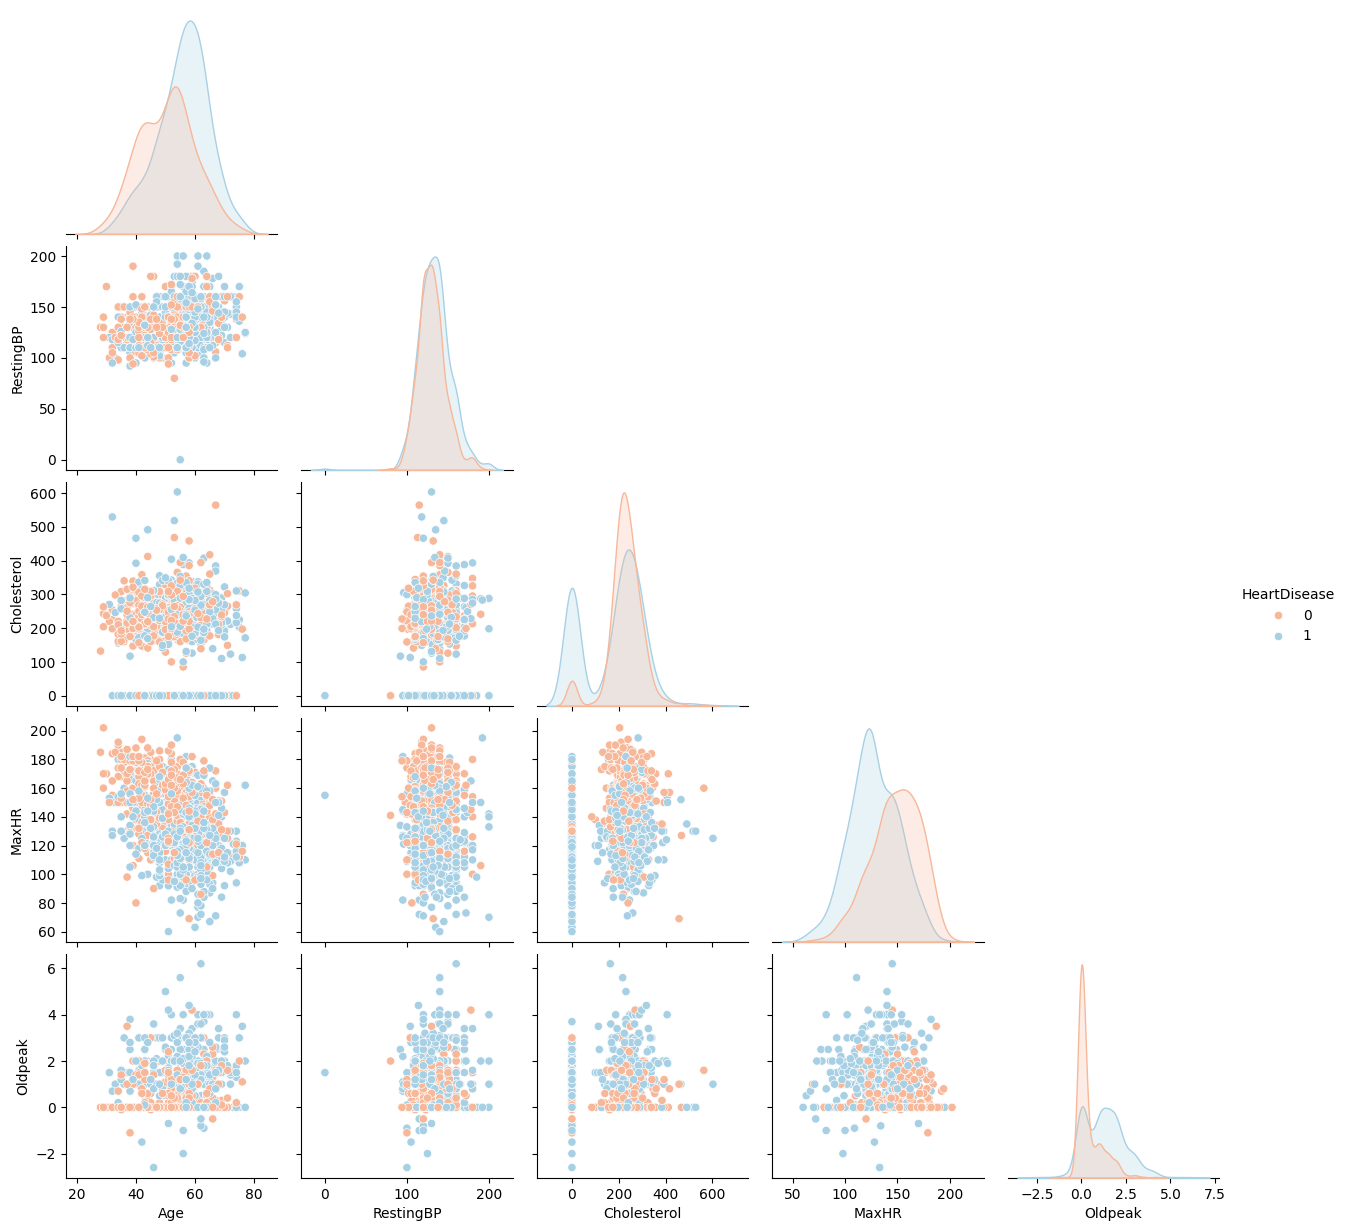

In [14]:
# Select only continuous columns + the target label
continuous_vars = ['Age', 'RestingBP', 'Cholesterol', 'MaxHR', 'Oldpeak', 'HeartDisease']

# Run the pairplot with the correct 'hue'
sns.pairplot(Heart_df[continuous_vars], hue="HeartDisease", corner=True, palette='RdBu')

Multivariate PairPlot shows that scatter plots show little corellation between variables, large blobs of scatter dots mixed together. KDE plots show overlap for each plots, with some separation, so PCA plots could show if they are linearly separable.

## PCA


In [15]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sc = StandardScaler()

In [16]:
y = Heart_df['HeartDisease']
X = Heart_df[continuous_vars]


X_scaled = sc.fit_transform(X)

### 2D PCA with 2 principal components

Explained variance: [0.34929752 0.20192943]


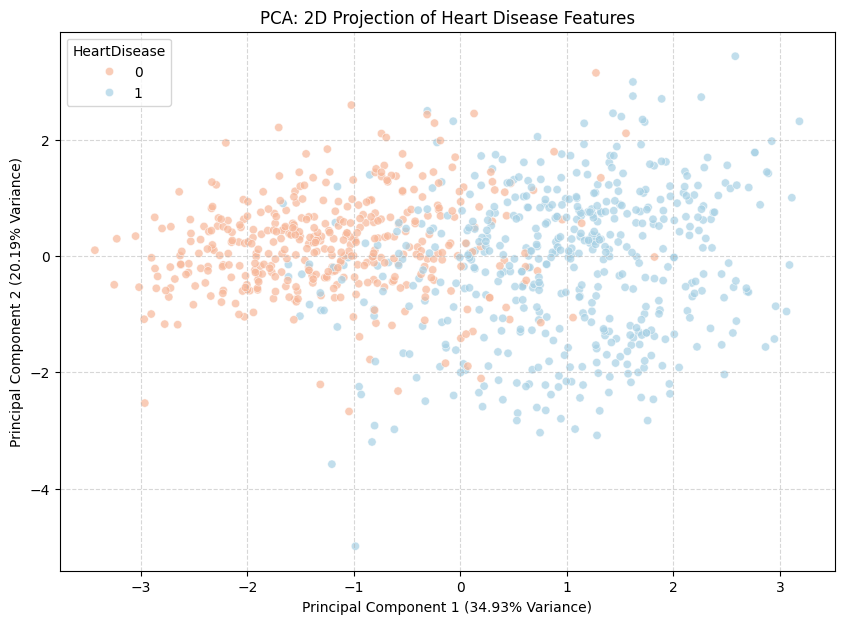

In [17]:
pca = PCA(n_components=2)
X_PCA = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
print (f"Explained variance: {explained_variance}")

pca_df = pd.DataFrame(data = X_PCA, columns = ['PC1', 'PC2'])

plt.figure(figsize=(10, 7))
sns.scatterplot(data=pca_df, x='PC1', y='PC2', hue=y, palette='RdBu', alpha=0.7)

plt.title('PCA: 2D Projection of Heart Disease Features')
plt.xlabel(f'Principal Component 1 ({explained_variance[0]:.2%} Variance)')
plt.ylabel(f'Principal Component 2 ({explained_variance[1]:.2%} Variance)')
plt.grid(True, linestyle='--', alpha=0.5)

The 2D PCA projection reveals distinct class separation primarily along the PC1 axis, which accounts for nearly 35% of the total variance. This indicates that a significant portion of the patient's prognosis is concentrated in a few key physiological features. While the first two components capture roughly 55% of the total variance, the clear spatial clustering suggests a high signal-to-noise ratio where a few variables are strong enough to maintain class separability even in a reduced feature space.

### Interactive 3d PCA plot

In [18]:
import plotly.express as px
pca = PCA(n_components=3)
X_PCA = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
print (f"Explained variance: {explained_variance}")

pca_df_3d = pd.DataFrame(data = X_PCA, columns = ['PC1', 'PC2', 'PC3'])

fig = px.scatter_3d(pca_df_3d, x='PC1', y='PC2', z='PC3', color=y, color_continuous_scale='RdBu_r')

fig.update_layout(margin=dict(l=0, r=0, b=0, t=40))
fig.show()

Explained variance: [0.34929752 0.20192943 0.15204853]


### Static 3d pca plot

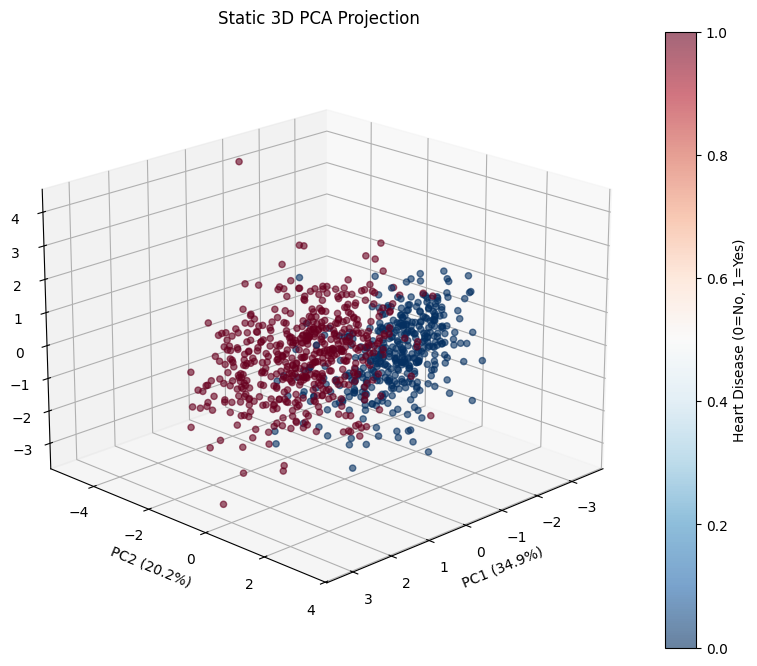

In [19]:
import matplotlib.pyplot as plt

# 1. Create the figure and 3D axis
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 2. Scatter plot
# We use 'y' for color, which you've already defined as your HeartDisease label
scatter = ax.scatter(pca_df_3d['PC1'], pca_df_3d['PC2'], pca_df_3d['PC3'], c=y, cmap='RdBu_r', alpha=0.6)

# 3. Labeling
ax.set_title('Static 3D PCA Projection')
ax.set_xlabel(f'PC1 ({explained_variance[0]:.1%})')
ax.set_ylabel(f'PC2 ({explained_variance[1]:.1%})')
ax.set_zlabel(f'PC3 ({explained_variance[2]:.1%})')

# 4. Set the viewing angle (Experiment with these numbers!)
ax.view_init(elev=20, azim=45) 

# 5. Add a color bar
plt.colorbar(scatter, label='Heart Disease (0=No, 1=Yes)')

plt.savefig("static_pca_plot.png", dpi=300)
plt.show()

3D PCA's scatter plot shows more clearly separated groups in a 3d plot with more concentrated clustering and separability between the two groups, with some overlaps between the two groups. 3 PCs altogether explains 70% of the variance, suggests that there are a few more variables used to help indicate disease group, high signal-to-noise ratio.
Dimensionality reduction reveals that while heart disease diagnosis is multivariate and confirms features are robust clinical features shown by clear separation between groups (with high clustering for each group) 

## Domain-Driven Feature Creation - Process raw numbers into categorical variables for fine-grained analysis

### Feature engineering of cholesterol levels, taken from 

[https://my.clevelandclinic.org/health/articles/11920-cholesterol-numbers-what-do-they-mean]


In [20]:
# Create an independent copy of the two columns
Cholesterol_df = Heart_df[['Cholesterol', 'HeartDisease']].copy()
Cholesterol_df['Above_200'] = Cholesterol_df['Cholesterol'] > 200 # Above 200 means at_risk of heart disease

Cholesterol_df.head()

,Cholesterol,HeartDisease,Above_200
0,289,0,True
1,180,1,False
2,283,0,True
3,214,1,True
4,195,0,False


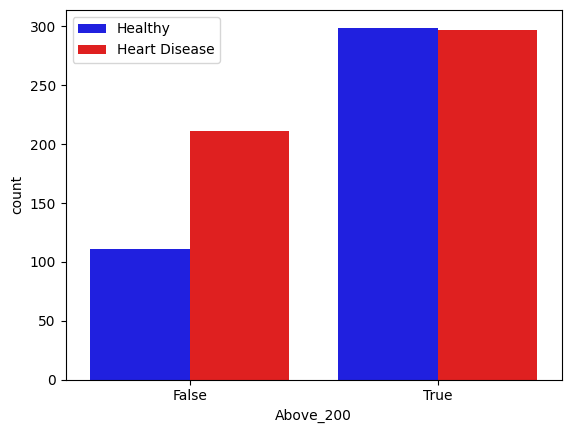

In [21]:
# Bar chart with categorical variables

sns.countplot(data=Cholesterol_df, x=Cholesterol_df.Above_200, hue=Cholesterol_df.HeartDisease, palette=['blue', 'red'])
plt.legend(['Healthy', 'Heart Disease'])
plt.show()

Analysis of cholesterol levels reveals a non-linear relationship with diagnosis: while the total count of heart disease cases is higher in the 'Above 200' group, the relative proportion of disease is significantly higher in the 'Below 200' group. This suggests that low cholesterol in this dataset is not a standalone indicator of health and may be influenced by external factors like medication or data outliers.

### Feature engineering for Resting blood pressure:

https://www.heart.org/en/health-topics/high-blood-pressure/understanding-blood-pressure-readings#:~:text=Table_title:%20Blood%20Pressure%20Categories%20Table_content:%20header:%20%7C,%7C%20DIASTOLIC%20mm%20Hg%20(bottom/lower%20number):%20%7C

https://pubmed.ncbi.nlm.nih.gov/35728416/

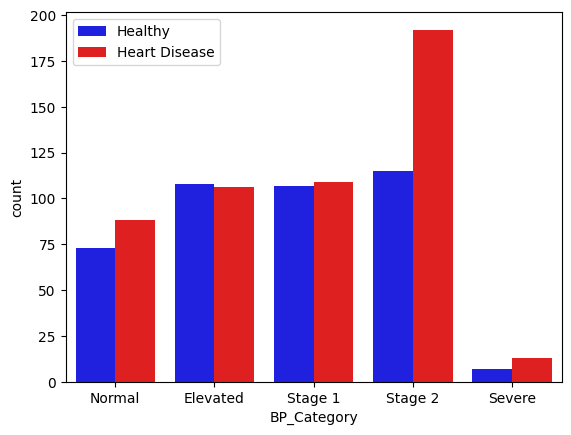

In [22]:
# Create an independent copy of the two columns
BP_df = Heart_df[['RestingBP', 'HeartDisease']].copy()

bins = [0, 120, 130, 140, 180, np.inf]
labels = ['Normal', 'Elevated', 'Stage 1', 'Stage 2', 'Severe']

BP_df['BP_Category'] = pd.cut(BP_df.RestingBP, bins=bins, 
                              labels=labels, include_lowest=True, right = False)

# bar chart with bp labels
sns.countplot(data=BP_df, x=BP_df.BP_Category, hue=BP_df.HeartDisease, palette=['blue', 'red'])
plt.legend(['Healthy', 'Heart Disease'])
plt.show()

Categorical analysis identifies Stage 2 Hypertension as a critical diagnostic tipping point, exhibiting the highest relative proportion of heart disease cases. Interestingly, the risk profile appears non-linear as the 'Elevated' and 'Stage 1' categories show a nearly balanced distribution while the 'Severe' category suffers from data sparsity from survivorship bias. This lack of data in the highest bracket likely suggests survivorship bias, where patients with extreme hypertension are either treated aggressively or suffer acute events before being recorded in elective diagnostic datasets.

### Feature Engineering for age range
https://service-manual.nhs.uk/content/inclusive-content/age

In [23]:
# Create an independent copy of the two columns
Age_df = Heart_df[['Age', 'HeartDisease']].copy()

bins = [0, 10, 21, 31, 41, 51, 61, 71, 81, 91, np.inf]
labels = ['0-10', '11-20', '21-30', '31-40', '41-50', '51-60', '61-70', '71-80', '81-90', '91+']

Age_df['Age_Category'] = pd.cut(Age_df.Age, bins=bins, 
                              labels=labels, include_lowest=True, right = False)

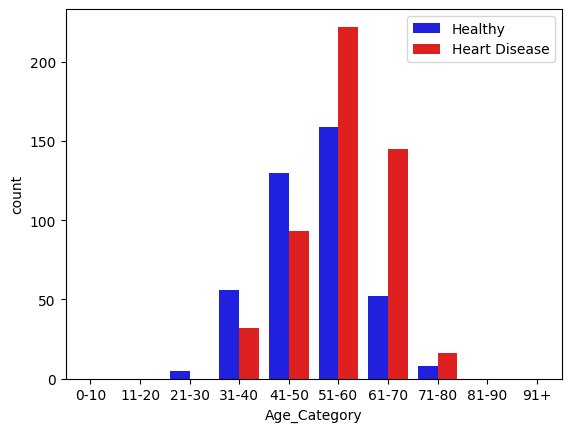

In [24]:
# bar chart with age labels
sns.countplot(data=Age_df, x=Age_df.Age_Category, hue=Age_df.HeartDisease, palette=['blue', 'red'])
plt.legend(['Healthy', 'Heart Disease'])
plt.show()

Age-stratified analysis reveals a clear trend of increasing heart disease prevalence, with a significant risk inflection point occurring after age 50. While the 51-60 cohort represents the highest total volume of cases, the 61-70 cohort exhibits the highest relative proportion of diseased vs. healthy instances. The subsequent decline in data volume for ages 71+ suggests a likely survivorship bias, while the sparsity in patients under 40 confirms that heart disease is primarily a condition of late-middle and older age. Notably, for those under 50, the data shows a dominant proportion of healthy individuals, further emphasizing that age is one of the most robust predictors of disease presence.